In [2]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

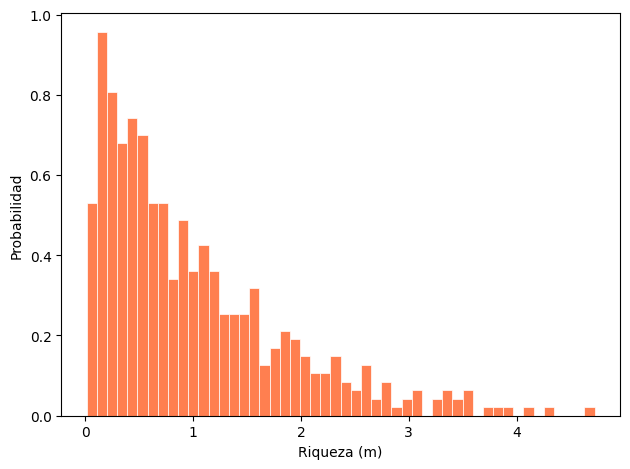

In [3]:
M=5e4
N=500
Money_prom = np.load('Pm_full.npy')/(M/N)

plt.hist(Money_prom[4], bins=50, density=True, color='coral', edgecolor='white', linewidth=0.5)

plt.xlabel('Riqueza (m)')
plt.ylabel('Probabilidad')

plt.tight_layout()
plt.show()

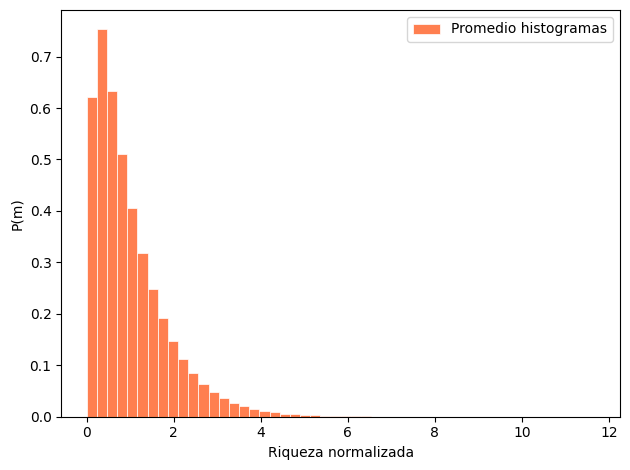

In [4]:
M = 5e4
N = 500
data = np.load('Pm_full.npy') / (M/N)  # shape (N_simulations, 500)

# Definir bins fijos para que todos los histogramas sean comparables
bins = np.linspace(0, data.max(), 51)  # 50 bins, mismos para todos
bin_centers = (bins[:-1] + bins[1:]) / 2

# Calcular histograma de cada simulación y apilarlos
densities = np.array([
    np.histogram(data[i], bins=bins, density=True)[0]
    for i in range(data.shape[0])
])

# Promediar bin a bin
density_mean = densities.mean(axis=0)

# Graficar
plt.bar(bin_centers, density_mean, width=np.diff(bins),
        color='coral', edgecolor='white', linewidth=0.5, label='Promedio histogramas')


plt.xlabel('Riqueza normalizada')
plt.ylabel('P(m)')
plt.legend()
plt.tight_layout()
plt.show()

α (shape) = 1.3996
θ (scale) = 0.7145
media     = 1.0000  (debe ser ~1.0)


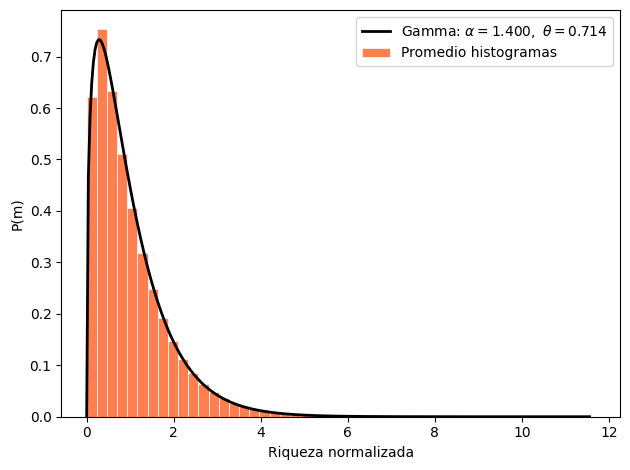


KS stat = 0.0128,  p-value = 0.0000


In [6]:
from scipy.stats import gamma

M = 5e4
N = 500
data = np.load('Pm_full.npy') / (M/N)

bins = np.linspace(0, data.max(), 51)
bin_centers = (bins[:-1] + bins[1:]) / 2

densities = np.array([
    np.histogram(data[i], bins=bins, density=True)[0]
    for i in range(data.shape[0])
])
density_mean = densities.mean(axis=0)

# Ajuste gamma sobre todos los datos aplanados
data_flat = data.flatten()
alpha, loc, scale = gamma.fit(data_flat, floc=0)  # loc=0 fijo

print(f"α (shape) = {alpha:.4f}")
print(f"θ (scale) = {scale:.4f}")
print(f"media     = {alpha * scale:.4f}  (debe ser ~1.0)")

# Curva ajustada
x_fit = np.linspace(0, bin_centers.max(), 300)
y_fit = gamma.pdf(x_fit, a=alpha, loc=0, scale=scale)

# Graficar
plt.bar(bin_centers, density_mean, width=np.diff(bins),
        color='coral', edgecolor='white', linewidth=0.5, label='Promedio histogramas')
plt.plot(x_fit, y_fit, 'k-', lw=2,
         label=fr'Gamma: $\alpha={alpha:.3f},\ \theta={scale:.3f}$')

plt.xlabel('Riqueza normalizada')
plt.ylabel('P(m)')
plt.legend()
plt.tight_layout()
plt.show()

# Bondad de ajuste
from scipy.stats import kstest
stat, p = kstest(data_flat, 'gamma', args=(alpha, 0, scale))
print(f"\nKS stat = {stat:.4f},  p-value = {p:.4f}")